<a href="https://www.kaggle.com/code/sriharikrishnants/final-of-task-2c?scriptVersionId=247425253" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# ... rest of your imports and code

In [3]:
import pandas as pd
import numpy as np
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [5]:
df = pd.read_json('/kaggle/input/news-category-dataset/News_Category_Dataset_v3.json',lines=True)
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


Now we need to combine the headline and short description into a single column

In [6]:
df['text'] = df['headline'] + " " + df['short_description']
df.head()

,link,headline,category,short_description,authors,date,text
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,Over 4 Million Americans Roll Up Sleeves For O...
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,"American Airlines Flyer Charged, Banned For Li..."
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,23 Of The Funniest Tweets About Cats And Dogs ...
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,The Funniest Tweets From Parents This Week (Se...
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,Woman Who Called Cops On Black Bird-Watcher Lo...


Lets remove the unecessary things like 'link' which dont contribute any meaningful things to our dataset

In [7]:
df = df[['text','category']]
df.head()

,text,category
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY
3,The Funniest Tweets From Parents This Week (Se...,PARENTING
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS


In [8]:
df['text'][0]

'Over 4 Million Americans Roll Up Sleeves For Omicron-Targeted COVID Boosters Health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the U.S. ordered for the fall.'

Lets remove the punctuations and Special characters

In [9]:
import re #regular expression
def clean_text(text):
    text = text.lower()
    #removes these extra characters
    text = re.sub(r'[^a-z0-9\s]','',text)
    text = re.sub(r'\s+',' ',text).strip()
    return text

In [10]:
df['cleaned_text'] = df['text'].apply(clean_text)
df.head()

,text,category,cleaned_text
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,over 4 million americans roll up sleeves for o...
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,american airlines flyer charged banned for lif...
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,23 of the funniest tweets about cats and dogs ...
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,the funniest tweets from parents this week sep...
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,woman who called cops on black birdwatcher los...


In [11]:
df['cleaned_text'][0]

'over 4 million americans roll up sleeves for omicrontargeted covid boosters health experts said it is too early to predict whether demand would match up with the 171 million doses of the new boosters the us ordered for the fall'

Now it will be easy to deal with 

**Now we can do Tokenization**

the process of breaking down a continuous stream of text into smaller, meaningful units called "tokens"



In [12]:
df['Tokens'] = df['cleaned_text'].apply(lambda x : x.split())

In [13]:
df.head()

,text,category,cleaned_text,Tokens
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,over 4 million americans roll up sleeves for o...,"[over, 4, million, americans, roll, up, sleeve..."
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,american airlines flyer charged banned for lif...,"[american, airlines, flyer, charged, banned, f..."
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,23 of the funniest tweets about cats and dogs ...,"[23, of, the, funniest, tweets, about, cats, a..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,the funniest tweets from parents this week sep...,"[the, funniest, tweets, from, parents, this, w..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,woman who called cops on black birdwatcher los...,"[woman, who, called, cops, on, black, birdwatc..."


Next step is to build **Vocabulary**

its a kind of dictionary of all the words in our dataset and assigns a numerical index to each token

In [14]:
all_words = [word for tokens in df['Tokens'] for word in tokens]
#Counter creates a dictionary of all words as keys and their frequencies as respective values
word_counts = Counter(all_words)

#limit Vocabulary size to prevent very rare words from bloating it
#reduce extremely infrequent words(to reduce memory and computational cost)
VOCAB_SIZE = 20000
#<pad> - to match the length sequence
#<unk> - to represent unknown words which are not in our vocab
vocab = ['<pad>','<unk>'] + [word for word,count in word_counts.most_common(VOCAB_SIZE - 2)]
word_to_idx = {word:idx for idx,word in enumerate(vocab)}
idx_to_word = {idx:word for word,idx in word_to_idx.items()}

In [15]:
print(f'Vocabulary size: {len(vocab)}')

Vocabulary size: 20000


Convert tokens to numerical sequence

In [16]:
def text_to_sequence(tokens,word_to_idx):
    #word_to_idx(word, default) checks if word exist or else return the default
    return [word_to_idx.get(word,word_to_idx['<unk>']) for word in tokens]

df['indexed_tokens'] = df['Tokens'].apply(lambda x: text_to_sequence(x,word_to_idx))


In [17]:
df.head()

,text,category,cleaned_text,Tokens,indexed_tokens
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,over 4 million americans roll up sleeves for o...,"[over, 4, million, americans, roll, up, sleeve...","[72, 428, 269, 263, 2218, 52, 11474, 9, 1, 657..."
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,american airlines flyer charged banned for lif...,"[american, airlines, flyer, charged, banned, f...","[170, 1526, 10735, 1391, 3059, 9, 74, 58, 9915..."
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,23 of the funniest tweets about cats and dogs ...,"[23, of, the, funniest, tweets, about, cats, a...","[2331, 5, 2, 1727, 735, 26, 2401, 6, 1015, 17,..."
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,the funniest tweets from parents this week sep...,"[the, funniest, tweets, from, parents, this, w...","[2, 1727, 735, 23, 182, 17, 99, 4102, 1, 4075,..."
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,woman who called cops on black birdwatcher los...,"[woman, who, called, cops, on, black, birdwatc...","[207, 49, 354, 1245, 11, 164, 1, 2849, 1337, 1..."


**Label encoding**

we need to convert the category column to labels to learn from

In [18]:
label_encoder = LabelEncoder()
df['encoded_category'] = label_encoder.fit_transform(df['category'])
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
df.head()

Number of classes: 42
Class names: ['ARTS' 'ARTS & CULTURE' 'BLACK VOICES' 'BUSINESS' 'COLLEGE' 'COMEDY'
 'CRIME' 'CULTURE & ARTS' 'DIVORCE' 'EDUCATION' 'ENTERTAINMENT'
 'ENVIRONMENT' 'FIFTY' 'FOOD & DRINK' 'GOOD NEWS' 'GREEN' 'HEALTHY LIVING'
 'HOME & LIVING' 'IMPACT' 'LATINO VOICES' 'MEDIA' 'MONEY' 'PARENTING'
 'PARENTS' 'POLITICS' 'QUEER VOICES' 'RELIGION' 'SCIENCE' 'SPORTS' 'STYLE'
 'STYLE & BEAUTY' 'TASTE' 'TECH' 'THE WORLDPOST' 'TRAVEL' 'U.S. NEWS'
 'WEDDINGS' 'WEIRD NEWS' 'WELLNESS' 'WOMEN' 'WORLD NEWS' 'WORLDPOST']


,text,category,cleaned_text,Tokens,indexed_tokens,encoded_category
0,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,over 4 million americans roll up sleeves for o...,"[over, 4, million, americans, roll, up, sleeve...","[72, 428, 269, 263, 2218, 52, 11474, 9, 1, 657...",35
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,american airlines flyer charged banned for lif...,"[american, airlines, flyer, charged, banned, f...","[170, 1526, 10735, 1391, 3059, 9, 74, 58, 9915...",35
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,23 of the funniest tweets about cats and dogs ...,"[23, of, the, funniest, tweets, about, cats, a...","[2331, 5, 2, 1727, 735, 26, 2401, 6, 1015, 17,...",5
3,The Funniest Tweets From Parents This Week (Se...,PARENTING,the funniest tweets from parents this week sep...,"[the, funniest, tweets, from, parents, this, w...","[2, 1727, 735, 23, 182, 17, 99, 4102, 1, 4075,...",22
4,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,woman who called cops on black birdwatcher los...,"[woman, who, called, cops, on, black, birdwatc...","[207, 49, 354, 1245, 11, 164, 1, 2849, 1337, 1...",35


Now our data is ready we can split the data into train and test and proceed futher

In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    df['indexed_tokens'],
    df['encoded_category'],
    test_size=0.35,
    random_state=42,
    stratify=df['encoded_category'] # Ensure class distribution is similar
)

In [20]:
X_train.head()

152006    [1061, 2, 1963, 2, 30, 5143, 5, 634, 346, 4, 1...
89066     [9965, 2715, 1584, 2707, 12030, 757, 869, 4102...
61879     [1586, 11944, 1586, 6, 4028, 7344, 75, 8, 41, ...
208592    [31, 95, 4149, 40, 519, 4149, 1160, 64, 684, 5...
97724                                            [57, 1388]
Name: indexed_tokens, dtype: object

In [21]:
y_train.head()

152006    38
89066     33
61879     20
208592    30
97724      5
Name: encoded_category, dtype: int64

Since there are no pre loaded dataset to deal with these datas

we need to define our own

In [22]:
# Custom Dataset Class
class NewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return torch.tensor(self.sequences.iloc[idx], dtype=torch.long), \
               torch.tensor(self.labels.iloc[idx], dtype=torch.long)

In [23]:
train_dataset = NewsDataset(X_train, y_train)
val_dataset = NewsDataset(X_val, y_val)

**To ensures that sequences in a batch are padded to the same length for efficient GPU processing, we use this function**

In [24]:
def collate_batch(batch):
    #unpacking the list of tuples
    sequences, labels = zip(*batch)
    # pad_sequence pads to the longest sequence in the batch
    # It takes a list of tensors and pads them to the max length in the batch.
    # padding_value=0 corresponds to '<pad>' token.
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=word_to_idx['<pad>'])
    labels = torch.tensor(labels, dtype=torch.long)
    return padded_sequences, labels

In [25]:
#Build DataLoader
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

In [26]:
print(f"\nTrain samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Number of train batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")


Train samples: 136192
Validation samples: 73335
Number of train batches: 2128
Number of validation batches: 1146


In [27]:
text,label = train_dataset[0]
text.shape

torch.Size([51])

In [28]:
EMBEDDING_DIM = 100
#the dimension of embedding matrix(the no of columns) is a hyper parameter
HIDDEN_DIM = 256
OUTPUT_DIM = num_classes # Number of unique categories
DROPOUT = 0.4

Build model

In [29]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=word_to_idx['<pad>'])

        # Layer 1
        self.input_to_hidden_1 = nn.Linear(embedding_dim, hidden_dim)
        self.hidden_to_hidden_1 = nn.Linear(hidden_dim, hidden_dim)

        # Layer 2
        self.input_to_hidden_2 = nn.Linear(hidden_dim, hidden_dim)
        self.hidden_to_hidden_2 = nn.Linear(hidden_dim, hidden_dim)

        # Layer 3
        self.input_to_hidden_3 = nn.Linear(hidden_dim, hidden_dim)
        self.hidden_to_hidden_3 = nn.Linear(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(dropout)
        self.tanh = nn.Tanh()
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        # text shape: [batch_size, seq_len]
        batch_size, seq_len = text.shape
        embedded = self.dropout(self.embedding(text))  # [batch, seq_len, embedding_dim]

        # Initialize hidden states for all 3 layers
        h1 = torch.zeros(batch_size, self.hidden_dim).to(text.device)
        h2 = torch.zeros(batch_size, self.hidden_dim).to(text.device)
        h3 = torch.zeros(batch_size, self.hidden_dim).to(text.device)

        hidden_states = []

        for t in range(seq_len):
            x_t = embedded[:, t, :]  # [batch, embedding_dim]

            # Layer 1
            h1 = self.tanh(self.input_to_hidden_1(x_t) + self.hidden_to_hidden_1(h1))

            # Layer 2
            h2 = self.tanh(self.input_to_hidden_2(h1) + self.hidden_to_hidden_2(h2))

            # Layer 3
            h3 = self.tanh(self.input_to_hidden_3(h2) + self.hidden_to_hidden_3(h3))

            hidden_states.append(h3.unsqueeze(1))  # [batch, 1, hidden_dim]

        # Mean pooling over time
        h_all = torch.cat(hidden_states, dim=1)  # [batch, seq_len, hidden_dim]
        h_avg = h_all.mean(dim=1)  # [batch, hidden_dim]

        out = self.fc(self.dropout(h_avg))  # [batch, output_dim]
        return out

In [35]:
rnn_model = RNNModel(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT).to(device)

In [52]:
N_EPOCHS = 15
CLIP = 1.0 # Gradient clipping value
LEARNING_RATE = 0.001

In [67]:
rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=LEARNING_RATE)
rnn_criterion = nn.CrossEntropyLoss().to(device)

In [58]:
from timeit import default_timer as timer
def find_time(start,end,device):
    total_sec = end-start
    hours = total_sec // 3600
    minutes = (total_sec % 3600 ) // 60
    rem_sec = total_sec % 60

    if hours > 0:
        print(f"total training time on {device} : {int(hours)} hrs {int(minutes)} minutes {int(rem_sec)} seconds")
    else:
        print(f"total training time on {device} : {int(minutes)} minutes and {int(rem_sec)} seconds")

In [57]:
def train_model(model, iterator, optimizer, criterion, clip, device):
    model.train()
    epoch_loss = 0
    correct_predictions = 0
    total_samples = 0

    for batch_idx, (text, labels) in enumerate(iterator):
        text, labels = text.to(device), labels.to(device)

        optimizer.zero_grad()
        predictions = model(text)
        loss = criterion(predictions, labels)

        loss.backward()

        #just to prevent exploding gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item() * len(labels)

        _, predicted_labels = torch.max(predictions, 1)
        correct_predictions += (predicted_labels == labels).sum().item()
        total_samples += len(labels)

    return epoch_loss / total_samples, (correct_predictions / total_samples) * 100


In [56]:
def evaluate_model(model,iterator,criterion,device):
    model.eval()
    epoch_loss=0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.inference_mode():
        for text,label in iterator:
            text,label = text.to(device),label.to(device)
            prediction = model(text)
            loss = criterion(prediction,label)

            epoch_loss += loss.item() * len(label)

            y_pred = torch.argmax(prediction,dim=1)
            correct += (y_pred == label).sum().item()
            total += label.size(0)

            all_predictions.extend(y_pred.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    
    avg_loss = epoch_loss / total
    accuracy = (correct / total) * 100
    
    return avg_loss,accuracy,all_predictions,all_labels

In [59]:
#do early stopping
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_acc = 0.0
        self.counter = 0
        self.early_stop = False

    def step(self, val_acc):
        if val_acc > self.best_val_acc + self.min_delta:
            self.best_val_acc = val_acc
            self.counter = 0  # reset patience counter
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

Training,Validation loop

In [ ]:
early_stopper = EarlyStopping(patience=3, min_delta=0.001)
best_val_accuracy = -float('inf')
start = timer()
for epoch in range(N_EPOCHS):
    train_loss,train_acc = train_model(rnn_model,train_loader,rnn_optimizer,rnn_criterion,CLIP,device)
    val_loss,val_acc = evaluate_model(rnn_model,val_loader,rnn_criterion,device)

    print(f"Epoch: {epoch+1:02}")
    print(f"\tRNN Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}%")
    print(f"\tRNN Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(rnn_model.state_dict(), 'best_rnn_model.pt')
        print("\tRNN: New best validation accuracy. Model saved!")

    # Early stopping logic
    early_stopper.step(val_acc)
    if early_stopper.early_stop:
        print(f"\nStopped early at epoch {epoch}. Best Val Acc = {early_stopper.best_val_acc:.4f}")
        break
        
end = timer()
find_time(start,end,device)

Testing loop

In [68]:
rnn_model.eval()
# rnn_model.load_state_dict(torch.load('best_rnn_model.pt'))
final_val_loss_rnn,final_val_acc_rnn,rnn_preds,rnn_labels = evaluate_model(rnn_model,val_loader,rnn_criterion,device)

print(f"final val loss: {final_val_loss_rnn:.3f} | final val accuracy: {final_val_acc_rnn:.3f}")

final val loss: 1.867 | final val accuracy: 51.400


In [ ]:
#save the model
import pickle
model_name = "my_rnn_model_3l.pkl"

with open(model_name,'wb') as f:
    pickle.dump(rnn_model,f)
print("model saved sucessfully")

In [65]:
#load the model again
import pickle
model_path = "/kaggle/input/3l_model/pytorch/default/1/my_rnn_model_3l.pkl"
with open(model_path,'rb') as f:
    rnn_model = pickle.load(f)
print("model loaded successfully")

model loaded successfully


**LSTM**

In [49]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=word_to_idx['<pad>'])

        # Input Gate components
        self.W_ii = nn.Linear(embedding_dim, hidden_dim, bias=True)
        self.W_hi = nn.Linear(hidden_dim, hidden_dim, bias=True)

        # Forget Gate components
        self.W_if = nn.Linear(embedding_dim, hidden_dim, bias=True)
        self.W_hf = nn.Linear(hidden_dim, hidden_dim, bias=True)

        # Cell Gate (Candidate Cell State) components
        self.W_ig = nn.Linear(embedding_dim, hidden_dim, bias=True)
        self.W_hg = nn.Linear(hidden_dim, hidden_dim, bias=True)

        # Output Gate components
        self.W_io = nn.Linear(embedding_dim, hidden_dim, bias=True)
        self.W_ho = nn.Linear(hidden_dim, hidden_dim, bias=True)

        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout_layer = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()

    def forward(self, text):
        # text = [batch_size, seq_len]
        batch_size, seq_len = text.shape

        embedded = self.dropout_layer(self.embedding(text))
        # embedded = [batch_size, seq_len, embedding_dim]

        # Initialize hidden and cell states
        h_t = torch.zeros(batch_size, self.hidden_dim).to(text.device) # [batch_size, hidden_dim]
        c_t = torch.zeros(batch_size, self.hidden_dim).to(text.device) # [batch_size, hidden_dim]

        # Loop through the sequence length
        for t in range(seq_len):
            x_t = embedded[:, t, :] # Get input at current time step t: [batch_size, embedding_dim]

            # Calculate gates using nn.Linear for each component
            i_t = self.sigmoid(self.W_ii(x_t) + self.W_hi(h_t))
            f_t = self.sigmoid(self.W_if(x_t) + self.W_hf(h_t))
            g_t = self.tanh(self.W_ig(x_t) + self.W_hg(h_t))
            o_t = self.sigmoid(self.W_io(x_t) + self.W_ho(h_t))

            # Update cell state
            c_t = f_t * c_t + i_t * g_t
            # Update hidden state
            h_t = o_t * self.tanh(c_t)

        # The final hidden state h_t is used for classification
        final_output = self.fc(self.dropout_layer(h_t)) # Apply dropout before final linear layer

        return final_output

In [43]:
lstm_model = LSTMModel(len(vocab), EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT).to(device)

In [53]:
lstm_optimizer = optim.Adam(lstm_model.parameters(),lr=LEARNING_RATE)
lstm_criterion = nn.CrossEntropyLoss().to(device)

In [54]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(lstm_optimizer, 
                                                       mode='max',       # Use 'min' for val_loss
                                                       patience=3,       # Wait 2 epochs before reducing LR
                                                       factor=0.5,       # Halve the LR
                                                       verbose=True, 
                                                       min_lr=1e-6)

In [46]:
best_val_accuracy = -float('inf')

In [49]:
early_stopper = EarlyStopping(patience=3, min_delta=0.001)
start = timer()
for epoch in range(N_EPOCHS):
    train_loss,train_acc = train_model(lstm_model,train_loader,lstm_optimizer,lstm_criterion,CLIP,device)
    val_loss,val_acc = evaluate_model(lstm_model,val_loader,lstm_criterion,device)

    print(f"Epoch : {epoch+1:02}")
    print(f"\tLSTM train loss: {train_loss:.3f} | LSTM train accuracy : {train_acc:.3f}%")
    print(f"\tLSTM val loss: {val_loss:.3f} | LSTM val accuracy : {val_acc:.3f}%")

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(lstm_model.state_dict(), 'best_lstm_model.pt')
        print("\tLSTM: New best validation accuracy. Model saved!")

    #scheduler step
    scheduler.step(val_acc)
    
    # Early stopping logic
    early_stopper.step(val_acc)
    if early_stopper.early_stop:
        print(f"\nStopped early at epoch {epoch}. Best Val Acc = {early_stopper.best_val_acc:.4f}%")
        break
end = timer()
find_time(start,end,device)

Epoch : 01
	LSTM train loss: 1.479 | LSTM train accuracy : 59.490%
	LSTM val loss: 1.483 | LSTM val accuracy : 59.738%
	LSTM: New best validation accuracy. Model saved!
Epoch : 02
	LSTM train loss: 1.431 | LSTM train accuracy : 60.580%
	LSTM val loss: 1.469 | LSTM val accuracy : 60.379%
	LSTM: New best validation accuracy. Model saved!
Epoch : 03
	LSTM train loss: 1.393 | LSTM train accuracy : 61.360%
	LSTM val loss: 1.434 | LSTM val accuracy : 61.002%
	LSTM: New best validation accuracy. Model saved!
Epoch : 04
	LSTM train loss: 1.355 | LSTM train accuracy : 62.186%
	LSTM val loss: 1.416 | LSTM val accuracy : 61.343%
	LSTM: New best validation accuracy. Model saved!
Epoch : 05
	LSTM train loss: 1.326 | LSTM train accuracy : 62.783%
	LSTM val loss: 1.405 | LSTM val accuracy : 61.649%
	LSTM: New best validation accuracy. Model saved!
Epoch : 06
	LSTM train loss: 1.295 | LSTM train accuracy : 63.618%
	LSTM val loss: 1.394 | LSTM val accuracy : 61.822%
	LSTM: New best validation accuracy.

Testing loop

In [61]:
lstm_model.eval()
# rnn_model.load_state_dict(torch.load('best_rnn_model.pt'))
final_val_loss_lstm,final_val_acc_lstm,lstm_preds,lstm_labels = evaluate_model(lstm_model,val_loader,lstm_criterion,device)

print(f"final val loss: {final_val_loss_lstm:.3f} | final val accuracy: {final_val_acc_lstm:.3f}")

final val loss: 1.373 | final val accuracy: 62.633


In [51]:
#save the model
import pickle
model_name = "my_lstm_model.pkl"

with open(model_name,'wb') as f:
    pickle.dump(lstm_model,f)
print("lstm model saved sucessfully")

lstm model saved sucessfully


In [50]:
#load the model again
import pickle
model_name1 = "/kaggle/input/lstm_model/pytorch/default1/1/my_lstm_model.pkl"

with open(model_name1,'rb') as f:
    lstm_model = pickle.load(f)
print("model loaded sucessfully")

model loaded sucessfully


Transfomer

In [34]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 128
HF_BATCH_SIZE = 32

In [35]:
#pre trained tokenizer for distilbet
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [36]:
torch.manual_seed(42)

In [37]:
TRAIN_VAL_SPLIT_RATIO = 0.2
print(f"\nPerforming train-validation split with test_size={TRAIN_VAL_SPLIT_RATIO}...")
train_df, val_df = train_test_split(
    df, # Split the original df
    test_size=TRAIN_VAL_SPLIT_RATIO,
    random_state=42,
    stratify=df['encoded_category'] # Ensure class distribution is similar in splits
)


Performing train-validation split with test_size=0.2...


In [38]:
print(f"Train samples after split: {len(train_df)}")
print(f"Validation samples after split: {len(val_df)}")

Train samples after split: 167621
Validation samples after split: 41906


In [39]:
class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        label = self.labels.iloc[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,        # Add '[CLS]' and '[SEP]'
            max_length=self.max_len,        # Pad/truncate to max_len
            return_token_type_ids=False,    # DistilBERT doesn't use token_type_ids for single segment
            padding='max_length',           # Pad to max_length
            truncation=True,                # Truncate if longer than max_len
            return_attention_mask=True,     # Return attention mask
            #a technique to selectively hide certain input tokens during the attention calculation, preventing them from influencing the attention weights
            return_tensors='pt',            # Return PyTorch tensors
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [40]:
hf_train_loader = DataLoader(
    TransformerDataset(train_df['text'], train_df['encoded_category'], tokenizer, MAX_LEN),
    batch_size=HF_BATCH_SIZE,
    shuffle=True
)
hf_val_loader = DataLoader(
    TransformerDataset(val_df['text'], val_df['encoded_category'], tokenizer, MAX_LEN),
    batch_size=HF_BATCH_SIZE,
    shuffle=False
)

In [41]:
print(f"Transformer Train samples: {len(hf_train_loader.dataset)}")
print(f"Transformer Validation samples: {len(hf_val_loader.dataset)}")
print(f"Number of Transformer train batches: {len(hf_train_loader)}")
print(f"Number of Transformer validation batches: {len(hf_val_loader)}")

Transformer Train samples: 167621
Transformer Validation samples: 41906
Number of Transformer train batches: 5239
Number of Transformer validation batches: 1310


In [42]:
print(f"Loading pre-trained {MODEL_NAME} model with classification head...")
transformer_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_classes).to(device)
print("Model loaded and moved to device.")

Loading pre-trained distilbert-base-uncased model with classification head...


2025-06-26 05:20:18.960716: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750915219.169129      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750915219.225469      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded and moved to device.


In [43]:
TRANSFORMER_LR = 2e-5 # Common learning rate for fine-tuning Transformers
transformer_optimizer = AdamW(transformer_model.parameters(), lr=TRANSFORMER_LR)
transformer_criterion = nn.CrossEntropyLoss().to(device)

In [44]:
def train_transformer_model(model, iterator, optimizer, device):
    model.train()
    epoch_loss = 0
    correct_predictions = 0
    total_samples = 0

    for batch_idx, batch in enumerate(iterator):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        
        # Transformer's forward pass returns an object, .loss and .logits are attributes
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss # Hugging Face models calculate loss automatically if labels are provided
        predictions = outputs.logits # Logits (raw scores) for classification

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Clip gradients to prevent exploding gradients
        optimizer.step()

        epoch_loss += loss.item() * len(labels) # Accumulate weighted loss
        
        _, predicted_labels = torch.max(predictions, 1) # Get the predicted class index
        correct_predictions += (predicted_labels == labels).sum().item() # Count correct predictions
        total_samples += len(labels) # Keep track of total samples processed

    return epoch_loss / total_samples, 100 * (correct_predictions / total_samples)

In [45]:
def evaluate_transformer_model(model, iterator, device):
    model.eval()
    epoch_loss = 0
    correct_predictions = 0
    total_samples = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad(): # Disable gradient calculations for evaluation
        for batch in iterator:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            predictions = outputs.logits

            epoch_loss += loss.item() * len(labels)

            _, predicted_labels = torch.max(predictions, 1)
            correct_predictions += (predicted_labels == labels).sum().item()
            total_samples += len(labels)

            all_predictions.extend(predicted_labels.cpu().numpy()) # Store predictions and labels for confusion matrix
            all_labels.extend(labels.cpu().numpy())

    avg_loss = epoch_loss / total_samples
    accuracy = 100 * (correct_predictions / total_samples)
    return avg_loss, accuracy, all_predictions, all_labels

Lets now do fine tuning

In [46]:
best_val_accuracy_transformer = -float('inf')
TRANSFORMER_N_EPOCHS = 3 # Transformers often converge faster and can overfit quickly

for epoch in range(TRANSFORMER_N_EPOCHS):
    train_loss_tf, train_acc_tf = train_transformer_model(transformer_model, hf_train_loader, transformer_optimizer, device)
    val_loss_tf, val_acc_tf,all_pred,all_label= evaluate_transformer_model(transformer_model, hf_val_loader, device)

    print(f"Epoch: {epoch+1:02}")
    print(f"\tTransformer Train Loss: {train_loss_tf:.3f} | Train Acc: {train_acc_tf:.2f}%")
    print(f"\tTransformer Val Loss: {val_loss_tf:.3f} | Val Acc: {val_acc_tf:.2f}%")

    if val_acc_tf > best_val_accuracy_transformer:
        best_val_accuracy_transformer = val_acc_tf
        # Save model state dict (best practice for saving/loading)
        torch.save(transformer_model.state_dict(), 'best_transformer_model.pt')
        print("\tTransformer: New best validation accuracy. Model saved!")


Epoch: 01
	Transformer Train Loss: 1.378 | Train Acc: 62.60%
	Transformer Val Loss: 1.063 | Val Acc: 68.82%
	Transformer: New best validation accuracy. Model saved!
Epoch: 02
	Transformer Train Loss: 0.925 | Train Acc: 72.58%
	Transformer Val Loss: 0.991 | Val Acc: 70.64%
	Transformer: New best validation accuracy. Model saved!
Epoch: 03
	Transformer Train Loss: 0.718 | Train Acc: 78.15%
	Transformer Val Loss: 1.028 | Val Acc: 70.71%
	Transformer: New best validation accuracy. Model saved!


In [47]:
# Load the best model weights for final evaluation
transformer_model.load_state_dict(torch.load('best_transformer_model.pt'))
final_val_loss_tf, final_val_acc_tf, tf_preds, tf_labels = evaluate_transformer_model(transformer_model, hf_val_loader, device)
print(f"\n--- Final Transformer Evaluation ---")
print(f"Transformer Final Val Loss: {final_val_loss_tf:.3f} | Final Val Acc: {final_val_acc_tf:.2f}%")


--- Final Transformer Evaluation ---
Transformer Final Val Loss: 1.028 | Final Val Acc: 70.71%


In [92]:
#save the model
import pickle
model_name = "transformer_model.pkl"
with open(model_name,'wb') as f:
    pickle.dump(transformer_model,f)
print("model saved successfully")

model saved successfully


In [93]:
ls -lh

total 767M
-rw-r--r-- 1 root root 256M Jun 26 07:00 best_transformer_model.pt
-rw-r--r-- 1 root root 256M Jun 26 07:26 transformer_model.pkl
-rw-r--r-- 1 root root 256M Jun 26 07:26 trasnformer_model.pkl


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


**Comparing the performance of the three models**

1.Accuracy comparison

In [72]:
print("\n--- 1. Accuracy Comparison ---")
print(f"RNN Final Validation Accuracy: {final_val_acc_rnn:.2f}%")
print(f"LSTM Final Validation Accuracy: {final_val_acc_lstm:.2f}%")
print(f"Transformer Final Validation Accuracy: {final_val_acc_tf:.2f}%")


--- 1. Accuracy Comparison ---
RNN Final Validation Accuracy: 51.40%
LSTM Final Validation Accuracy: 62.63%
Transformer Final Validation Accuracy: 70.71%


2.Confusion Matrix


 RNN Confusion Matirx

RNN  Confusion Matrix:


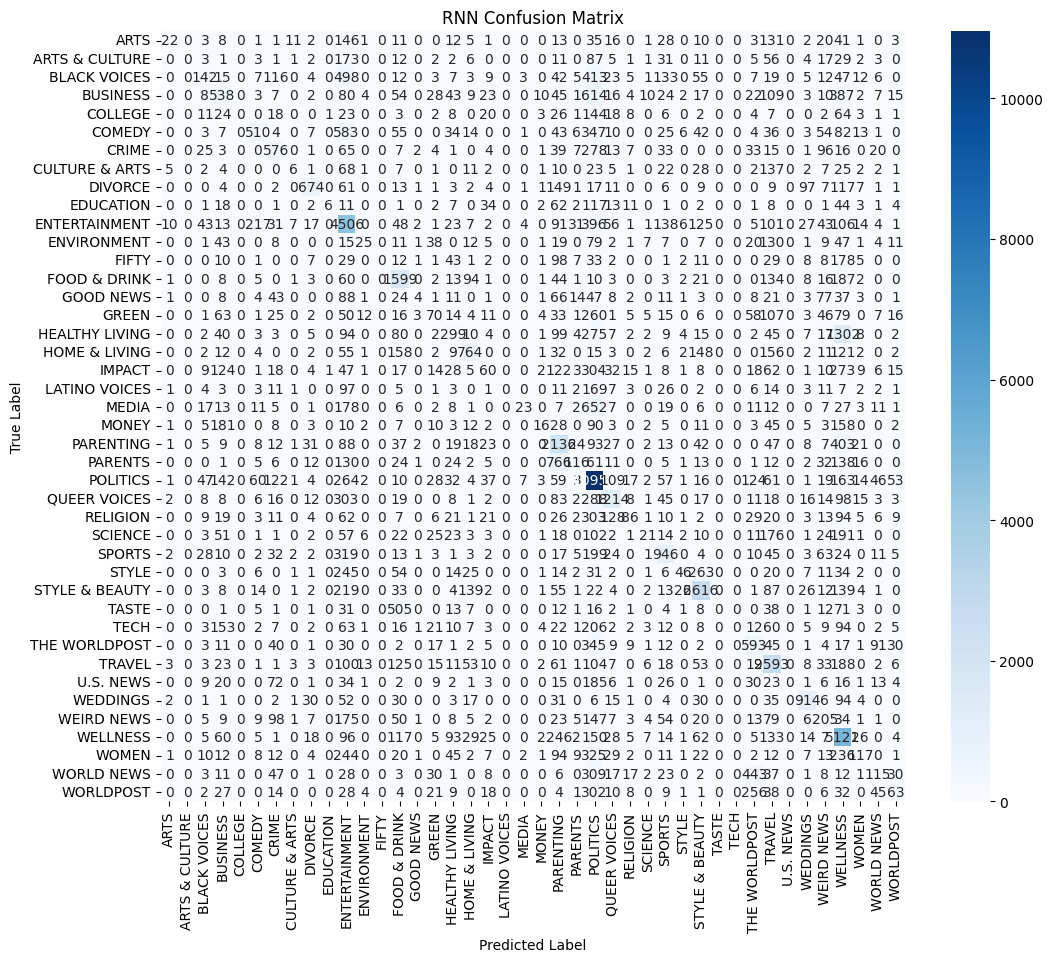


LSTM Confusion Matrix:


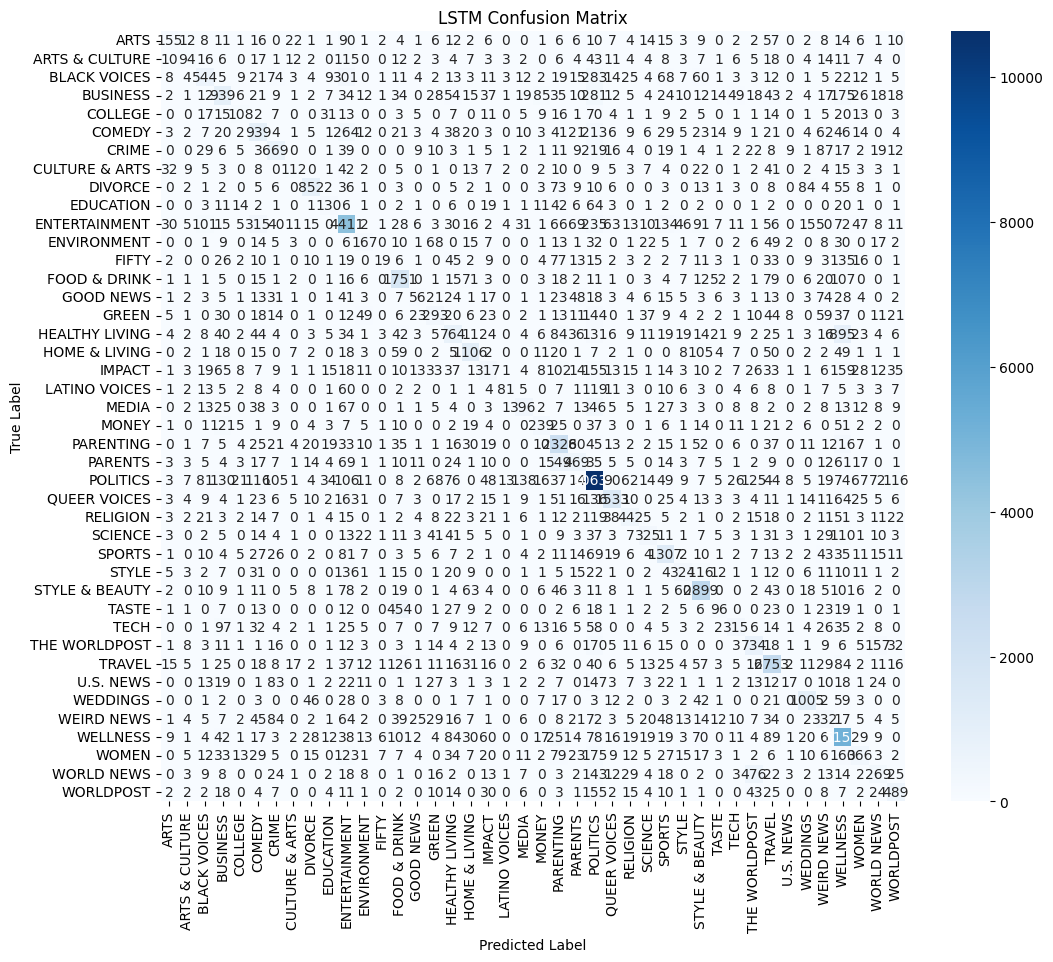


Transformer Confusion Matrix:


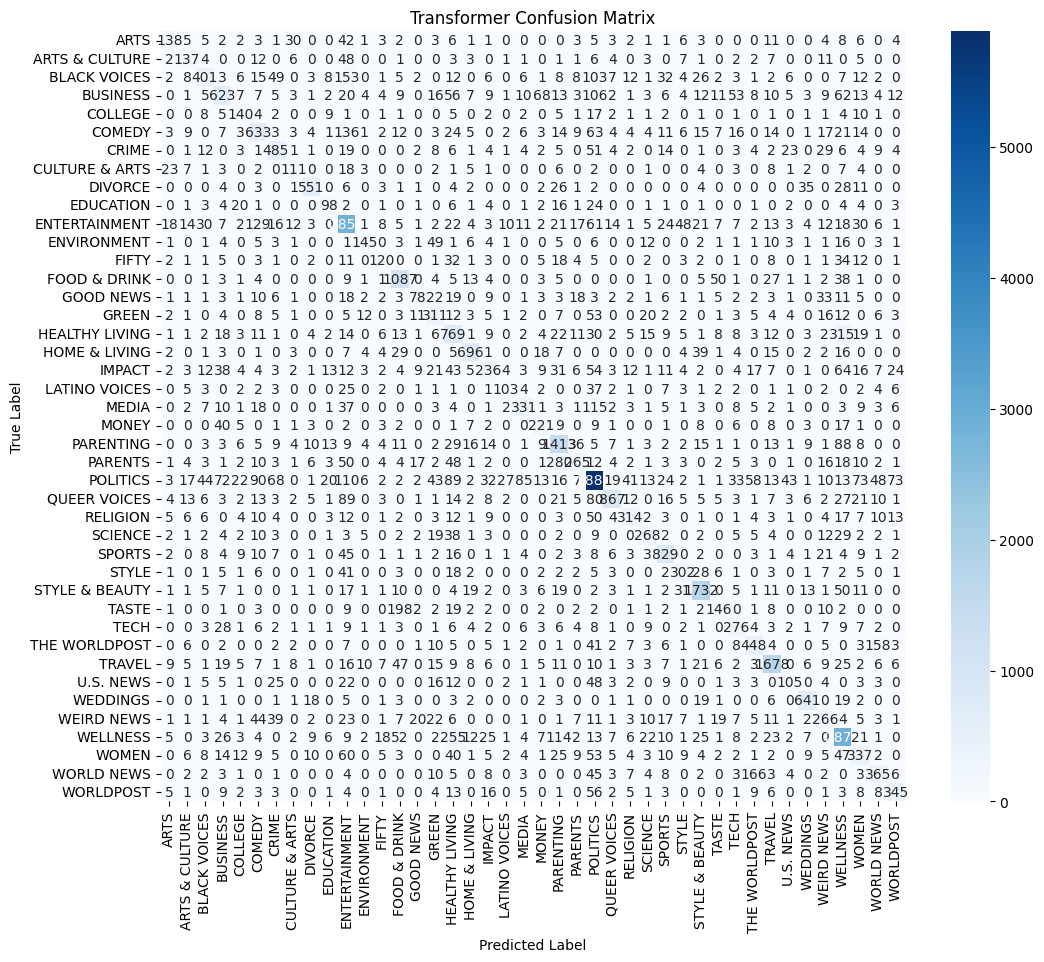

In [75]:
print(f"\n RNN Confusion Matirx")
print("\nRNN  Confusion Matrix:")
rnn_cm = confusion_matrix(rnn_labels, rnn_preds) 
plt.figure(figsize=(12, 10))
sns.heatmap(rnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('RNN Confusion Matrix')
plt.show()

print("\nLSTM Confusion Matrix:")
lstm_cm = confusion_matrix(lstm_labels, lstm_preds) 
plt.figure(figsize=(12, 10))
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LSTM Confusion Matrix')
plt.show()


print("\nTransformer Confusion Matrix:")
transformer_cm = confusion_matrix(tf_labels, tf_preds) 
plt.figure(figsize=(12, 10))
sns.heatmap(transformer_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Transformer Confusion Matrix')
plt.show()

Qualitative analysis

In [81]:
#predict single sample from
def predict_single_sample(model,text_tokens,word_to_idx,label_encoder,device):
    model.eval()
    indexed_text = torch.tensor([word_to_idx.get(word,word_to_idx['<unk>']) for word in text_tokens], dtype=torch.long).unsqueeze(0).to(device)
    with torch.inference_mode():
        output = model(indexed_text)
        predicted_idx = torch.argmax(output,1)
        #now we need to find the class
        #since we used label_encoder to create label
        predicted_class = label_encoder.inverse_transform(predicted_idx.cpu().numpy())[0]
    return predicted_class

In [82]:
def predict_single_sample_transformer(model, text, tokenizer, label_encoder, max_len, device):
    model.eval()
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_len,
        return_token_type_ids=False,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt', # Return PyTorch tensors
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predicted_label_idx = torch.argmax(logits, dim=1)
        predicted_class = label_encoder.inverse_transform(predicted_label_idx.cpu().numpy())[0]
    return predicted_class

In [85]:
sample_indices = np.random.choice(len(val_df), 5, replace=False) # Select 5 random samples

print("\nSelected Prediction Examples:")
for i, idx in enumerate(sample_indices):
    sample_row = val_df.iloc[idx]
    sample_text_raw = sample_row['text']            # Raw text for Transformer
    sample_tokens_rnn_lstm = sample_row['Tokens']   # Tokenized text for RNN/LSTM

    true_category_encoded = sample_row['encoded_category']
    true_category_name = label_encoder.inverse_transform([true_category_encoded])[0]

    # Get predictions from each model
    rnn_predicted_category = predict_single_sample(rnn_model, sample_tokens_rnn_lstm, word_to_idx, label_encoder, device)
    lstm_predicted_category = predict_single_sample(lstm_model, sample_tokens_rnn_lstm, word_to_idx, label_encoder, device)
    transformer_predicted_category = predict_single_sample_transformer(transformer_model, sample_text_raw, tokenizer, label_encoder, MAX_LEN, device)

    print(f"\n--- Sample {i+1} ---")
    print(f"Original Text: {sample_text_raw}")
    print(f"True Category: {true_category_name}")
    print(f"RNN (From Scratch) Predicted Category: {rnn_predicted_category}")
    print(f"LSTM (From Scratch) Predicted Category: {lstm_predicted_category}")
    print(f"Transformer Predicted Category: {transformer_predicted_category}")



Selected Prediction Examples:

--- Sample 1 ---
Original Text: Slideshow: Best Cruise Lines for Romance Maybe it's the fact that you and your better half can sail off into the sunset night after night, or maybe it's the ability to discover multiple locales while enjoying intimate meals, couples spa treatments and spacious cabins. Whatever the reason, cruises offer an inspiring setting for igniting romance.
True Category: TRAVEL
RNN (From Scratch) Predicted Category: WEDDINGS
LSTM (From Scratch) Predicted Category: TRAVEL
Transformer Predicted Category: TRAVEL

--- Sample 2 ---
Original Text: What You're Thankful For -- In One Word For most of us, it can be too easy to get swept up with the negative and focus on our complaints rather than our blessings
True Category: WELLNESS
RNN (From Scratch) Predicted Category: WELLNESS
LSTM (From Scratch) Predicted Category: WELLNESS
Transformer Predicted Category: WELLNESS

--- Sample 3 ---
Original Text: Oscars Greenroom 2013: Meet Madeline Stuar